[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/https://github.com/maurergroup/MLinCP/Module_V_Neural_Networks/WS5_Neural_Networks/WS5_Neural_Networks.ipynb)

# WS 5 — Neural Networks

**Machine Learning in Computational Physics** · University of Vienna

---

<div class="alert alert-block alert-danger">

**Assignment submission**

When you submit this notebook for assignment, make sure that all tasks below (blue boxes) are completed (with code) and all questions are answered (with extra markdown responses). Make sure that the notebook runs correctly when all cells are executed in the right order from top to bottom. Before submission, do not clear outputs. Leave all the outputs from the last run included.
</div>

## 0. Prelude

> ### Update your environment
> For this workshop, the Python environment has been updated with a few new packages. 
> Please make sure you regenerate your python environments. 
> 
> For Container users: 
> `docker compose build`
> 
> Without containers:
> `uv sync`
> 
> You may need to restart your VSCode session after doing this. 


In this workshop we will solve a classification problem using neural networks. Specifically, we will study the nucleation process of a simple model of water: monoatomic water (mW) in the parametrization introduced by Chan *et al.* [Chan2019].

The details of the interaction model are not particularly important for the purposes of this workshop, but additional information can be found in the original papers [Molinero2009, Chan2019]. The essential idea behind the model is that each water molecule is represented by a single particle, typically interpreted as an oxygen atom, while the effects of the hydrogen atoms are incorporated implicitly into the interaction potential.

Our goal is to train a neural network to recognize solid nuclei forming within a liquid environment and to classify them according to their crystalline symmetry. This is a particularly interesting problem from a physical perspective because water can crystallize into several different structures, and the presence of defects, interfaces, and thermal fluctuations makes the identification of local environments highly non-trivial.

To tackle this problem we will combine ideas from:
- molecular dynamics simulations,
- local structural descriptors,
- supervised machine learning,
- and trajectory visualization.

By the end of the workshop, we will be able to analyze a molecular dynamics trajectory and identify the emergence and growth of crystalline nuclei directly from the predictions of a neural network.

The idea for this workshop comes from two papers [Boattini2018, Coli2021], where similar approaches were used to study nucleation in binary mixtures of hard spheres. If you are interested, check these references for additional context.

The workshop will make use of several packages that you have already encountered, as well as some new ones that we will introduce today for the first time. The most important packages, besides the standard scientific Python libraries, are:

- [PyTorch](https://pytorch.org/): A machine learning framework based on tensor operations and automatic differentiation, with native GPU support. We will use PyTorch to build, train, and evaluate neural networks for structural classification.

- [Atomic Simulation Environment (ASE)](https://wiki.fysik.dtu.dk/ase/): A package used to store and manipulate molecular structures and their properties. ASE defines a flexible `Atoms` object that is widely used in atomistic machine-learning workflows.

- [MDAnalysis (MDA)](https://www.mdanalysis.org/): A Python library for loading, analyzing, and processing molecular dynamics trajectories. We will use MDAnalysis to read simulation trajectories and access atomic coordinates frame by frame.

- [pyscal3 (v. 4.0.0)](https://github.com/pyscal/pyscal3): A package for the analysis of local atomic environments in condensed matter systems. In this workshop we will use pyscal to compute local structural descriptors, such as Steinhardt bond-order parameters, which will serve as input features for the neural network.

As you work through the notebook and complete the exercises, consult the documentation pages of these packages whenever you get stuck or want to explore additional functionality.

In [ ]:
# As usual we import a bunch of libraries as a first thing
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm import tqdm

from ase import Atoms
import MDAnalysis as mda
import pyscal3 as pc
import pathlib
# Locate repo root (contains pyproject.toml) — works in Docker, VS Code, and local Jupyter
_p = pathlib.Path().resolve()
while not (_p / 'pyproject.toml').exists() and _p != _p.parent:
    _p = _p.parent
DATA_DIR = _p.joinpath('data')

## 1. Data Preparation and Analysis

To perform the supervised learning task, we first need a set of configurations whose structural identity is already known. In particular, we will use molecular dynamics trajectories of a system of $N=256$ molecules corresponding to several distinct phases of monoatomic water:

- cubic ice,
- hexagonal ice,
- liquid water,
- and an amorphous solid phase.

The cubic and hexagonal phases are two of the most common crystalline structures of ice under conditions close to ambient pressure. In addition, we will use a trajectory corresponding to the liquid state.

Finally, we also consider a trajectory obtained from a spontaneous nucleation event. Although this system is predominantly solid, the presence of defects, interfaces, and disordered regions prevents it from being classified cleanly as either cubic or hexagonal ice. For this reason, we will treat it as an amorphous phase. **For the moment, discard this trajectory and focus only on the cubic, hexagonal, and liquid trajectories.**

The trajectories can be found in the folder `/data/mW/N256/`, where each trajectory is stored as a binary file `mW.dcd` together with the corresponding topology file `topology.lammpsdump`, which is needed to decode the binary trajectory.

The corresponding [LAMMPS](https://docs.lammps.org/Manual.html) input files, `md.lmp` and `<phase>_256.lmp`, are also provided as a reference for the simulation parameters and initial configurations. Including these files is important for reproducibility.

The most important simulation detail for this workshop is the sampling frequency, which is **one configuration every $5$ ps**. This means that, even if all configurations are used, consecutive frames can be assumed to be at least approximately decorrelated.

Nevertheless, especially at the beginning of the workshop, it will likely be useful to subsample the trajectories in order to reduce memory usage and avoid saturating the RAM of your computer. Check the variables `frame_stride` and `max_frames` in the following cells.

It is also important to note that the trajectories were generated in the **constant-pressure ensemble**. As a consequence, the simulation box fluctuates during the trajectory. To fully characterize the system at each frame, we therefore need not only the atomic coordinates, but also the instantaneous box dimensions.

In [ ]:
path_to_cubic = DATA_DIR.joinpath("mW/N256/0-cubic")
path_to_hexagonal = DATA_DIR.joinpath("mW/N256/1-hexagonal")
path_to_liquid = DATA_DIR.joinpath("mW/N256/2-liquid")
# path_to_amorphous = DATA_DIR.joinpath("mW/N256/3-amorphous")

In [ ]:
# ============================================================
# Label definitions
# ============================================================
label_names = {
    0: "cubic",
    1: "hexagonal",
    2: "liquid",
    # 3: "amorphous"
}

# ============================================================
# Dataset definition
# ============================================================
datasets = {
    0: path_to_cubic,
    1: path_to_hexagonal,
    2: path_to_liquid,
    # 3: path_to_amorphous,
}

# ============================================================
# Variables definition
# ============================================================
frame_stride = 50 # Pick one frame from the trajectory every frame_stride
max_frames = np.inf # Set maximum number of frames to load

### Read and Analyse Molecular Dynamics Data

<div class="alert alert-block alert-info">

**TASK**

1. Use `MDAnalysis` to load the trajectories and then use `pyscal`, in combination with `ASE`, to analyze them. 

</div>

#### Radial Distribution Functions
As a first step, we can analyze the radial distribution functions of these systems to verify that they indeed correspond to different phases.

A topology file together with a trajectory in the binary `.dcd` format is provided as input to MDAnalysis, which then generates a `Universe` object:

```python
u = mda.Universe(
    f"{path}/topology.lammpsdump",
    f"{path}/mW.dcd",
    topology_format="LAMMPSDUMP"
)
```

At this point, the trajectory can be accessed frame by frame by looping over the `trajectory` attribute of the universe. The atomic positions and simulation cell corresponding to each frame can then be extracted:

```python
for iframe, ts in enumerate(tqdm(u.trajectory[::frame_stride], desc=phase_name)):
        
    positions = u.atoms.positions.copy()
    box = ts.dimensions[:3]
```

These coordinates can then be used to generate an ASE object representing the atomic structure of the current frame:

```python
ase_atoms = Atoms(
    symbols=["O"] * len(positions),
    positions=positions,
    cell=box,
    pbc=True
)
```

Finally, the resulting ASE object can be passed directly to pyscal for structural analysis.

```python
g_r, r = pc.radial_distribution_function(
    ase_atoms,
    rmax=rmax,
    bins=bins
)
```

/Users/spears/Documents/Projects/MLinCP/.venv/lib/python3.12/site-packages/MDAnalysis/topology/LAMMPSParser.py:670: UserWarning: Guessed all Masses to 1.0
  warnings.warn("Guessed all Masses to 1.0")
/Users/spears/Documents/Projects/MLinCP/.venv/lib/python3.12/site-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


Processing phase: cubic


cubic: 100%|██████████| 201/201 [00:01<00:00, 110.72it/s]


Processing phase: hexagonal


hexagonal: 100%|██████████| 201/201 [00:01<00:00, 118.32it/s]


Processing phase: liquid


liquid: 100%|██████████| 201/201 [00:02<00:00, 90.47it/s]


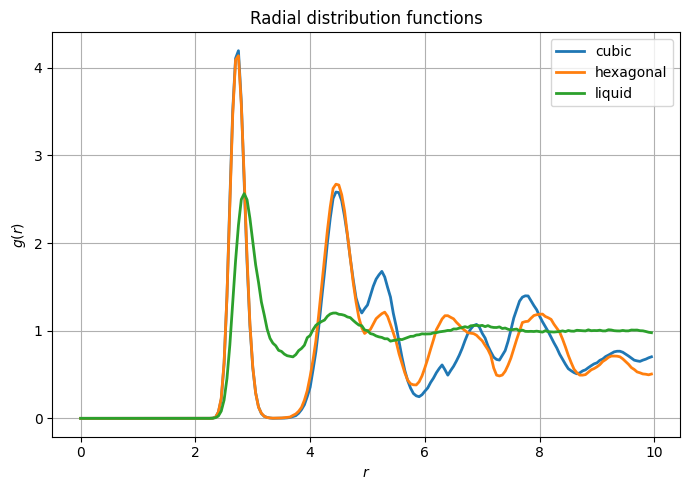

In [ ]:
# ============================================================
# RDF parameters
# ============================================================
rmax = 10.0
bins = 200

# ============================================================
# Storage
# ============================================================
rdf_results = {}

# ============================================================
# Loop over phases
# ============================================================
for label, path in datasets.items():

    phase_name = label_names[label]

    print(f"Processing phase: {phase_name}")

    # --------------------------------------------------------
    # Load trajectory
    # --------------------------------------------------------
    u = mda.Universe(
        f"{path}/topology.lammpsdump",
        f"{path}/mW.dcd",
        topology_format="LAMMPSDUMP"
    )

# --------------------------------------------------------
    # RDF accumulator
    # --------------------------------------------------------

    rdf_accumulator = []

    # --------------------------------------------------------
    # Loop over frames
    # --------------------------------------------------------

    for iframe, ts in enumerate(tqdm(u.trajectory[::frame_stride], desc=phase_name)):

        if max_frames is not None and iframe >= max_frames:
            break

        # ----------------------------------------------------
        # Coordinates and box
        # ----------------------------------------------------
        positions = u.atoms.positions.copy()
        box = ts.dimensions[:3]

        # ----------------------------------------------------
        # ASE atoms object
        # ----------------------------------------------------
        ase_atoms = Atoms(
            symbols=["O"] * len(positions),
            positions=positions,
            cell=box,
            pbc=True
        )

        # ----------------------------------------------------
        # RDF
        # ----------------------------------------------------
        g_r, r = pc.radial_distribution_function(
            ase_atoms,
            rmax=rmax,
            bins=bins
        )
        rdf_accumulator.append(g_r)

    # --------------------------------------------------------
    # Average RDF
    # --------------------------------------------------------
    rdf_accumulator = np.array(rdf_accumulator)
    g_r_mean = rdf_accumulator.mean(axis=0)
    g_r_std = rdf_accumulator.std(axis=0)

    # --------------------------------------------------------
    # Store
    # --------------------------------------------------------

    rdf_results[phase_name] = {
        "r": r,
        "g_r_mean": g_r_mean,
        "g_r_std": g_r_std
    }

# ============================================================
# Plot RDFs
# ============================================================
plt.figure(figsize=(7, 5))

for phase_name, rdf_data in rdf_results.items():
    plt.plot(
        rdf_data["r"],
        rdf_data["g_r_mean"],
        linewidth=2,
        label=phase_name
    )

plt.xlabel(r"$r$")
plt.ylabel(r"$g(r)$")
plt.title("Radial distribution functions")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 2. Generate Local Descriptors

#### Leichner-Dellago Bond Order Parameters

To characterize the local structural environment surrounding each particle, we will use the averaged bond-order parameters introduced by Lechner and Dellago [Lechner2008]. These quantities are rotationally invariant descriptors constructed from spherical harmonics and are widely used in the analysis of crystalline structures in molecular simulations.

The starting point is the definition of the complex bond-order coefficients

$$
q_{lm}(i)
=
\frac{1}{N_b(i)}
\sum_{j \in N_b(i)}
Y_{lm}(\mathbf{r}_{ij}),
$$

where:
- $Y_{lm}$ are spherical harmonics of order $l$ with $m$ an integer that runs from $m=-l$ to $m=l$,
- $\mathbf{r}_{ij}$ is the vector connecting particle $i$ to one of its neighbors $j$,
- and $N_b(i)$ is the number of neighbors of particle $i$.

The coefficients $q_{lm}$ encode information about the angular distribution of neighboring particles around a given atom.

Lechner and Dellago proposed averaging these quantities over both a particle and its neighbors:

$$
\bar{q}_{lm}(i)
=
\frac{1}{N_b(i)+1}
\sum_{k \in \{i, N_b(i)\}}
q_{lm}(k),
$$

which improves the robustness of the descriptors against thermal fluctuations and effectively incorporates information from next-nearest neighbors as well.

From these averaged coefficients, rotationally invariant scalar descriptors can be constructed. The quadratic order invariants are defined as

$$
\bar{q}_{l}(i)
=
\sqrt{
\frac{4\pi}{2l+1}
\sum_{m=-l}^{l}
|\bar{q}_{lm}(i)|^2
},
$$

while the cubic invariants are

$$
\bar{w}_{l}(i)
=
\frac{
\displaystyle
\sum_{m_1+m_2+m_3=0}
\begin{pmatrix}
l & l & l \\
m_1 & m_2 & m_3
\end{pmatrix}
\bar{q}_{lm_1}(i)
\bar{q}_{lm_2}(i)
\bar{q}_{lm_3}(i)
}{
\left(
\displaystyle
\sum_{m=-l}^{l}
|\bar{q}_{lm}(i)|^2
\right)^{3/2}
}
$$

which involve combinations of three spherical harmonics weighted by Wigner 3j symbols.

The quantities:
- $\bar{q}_l$,
- and $\bar{w}_l$,

are real, translationally and rotationally invariant and are sensitive to different local crystal symmetries depending on the choice of $l$. For example, cubic and hexagonal ice exhibit distinct signatures in these descriptors, making them excellent input features for machine learning models aimed at identifying local structural environments.

In this workshop we will compute several $\bar{q}_l$ and $\bar{w}_l$ descriptors for every particle in the system and use them as input features for a neural network classifier. **We will not implement the functions ourselves**, but we will let `pyscal` do it for us. To start, let's just select $l=4,6$ (note that, in general, odd values of $l$ are not used for $\bar{w}_l$ as they tend to cancel out for most crystal symmetries).

In [ ]:
# ============================================================
# Descriptor definitions
# ============================================================
# Second-order Steinhardt bond order parameters q_l.
q_ls = [
    # 2,
    # 3,
    4,
    # 5,
    6,
    # 7,
    # 8,
    ]

# Third-order Steinhardt invariant w_l.
w_ls = [
    # 2,
    4,
    6,
    # 8,
    ]

### Compute Feature Vectors from Molecular Dynamics Data

<div class="alert alert-block alert-info">

**TASK**

2. Use `MDAnalysis` to load the trajectories and then use `pyscal`, in combination with `ASE`, to compute the $l$-order quadratic and cubic steinhardt parameters. 

</div>

`pyscal` provides functions to compute $\bar{q}_l$ and $\bar{w}_l$ in their Leichner-Dellago formulation. It first takes care of building a neighbor list around particle $i$ and then it uses it to compute order parameters. To compute the neighbor list run

```python
pc.find_neighbors(ase_atoms, method="cutoff", cutoff=0)
```

this method uses an adaptive cutoff method discussed in Ref. [cite Stukowski, A, Model Simul Mater SC 20, 2012.]. The function returns `None`, as the result is stored in-place in the `atoms` object.

To compute the order parameters, use the functions:

```python
pc.steinhardt_parameter(ase_atoms, l=q_ls, averaged=True)
pc.wigner_w_parameter(ase_atoms, l=w_ls, averaged=True)
```

These descriptors are local, per-particle descriptors. Ideally, we would like to organize them into an array suitable for the supervised learning problem we want to solve. In particular, the descriptor tensor should have dimensions

$$
(N_{\mathrm{frames}},\ N_{\mathrm{particles}},\ N_{\mathrm{features}})
$$

where:
- $N_{\mathrm{frames}}$ is the number of configurations (or trajectory frames),
- $N_{\mathrm{particles}}$ is the number of particles in the system,
- and $N_{\mathrm{features}}$ is the dimension of the descriptor vector associated with each particle. 

In addition to the descriptors, which are the main goal of this task, we would also store in a compatible way the **labels**, i.e. to which structure corresponds each particle local environment, the **positions** of the configuration analyzed and the **box size** corresponding to the configurations.

In [ ]:
# ============================================================
# Storage
# ============================================================
all_descriptors = []
all_labels = []
all_positions = []
all_boxes = []

# ============================================================
# Loop over phases
# ============================================================
for label, path in datasets.items():

    print(f"\nProcessing label {label}")
    print(f"Path: {path}")

    # --------------------------------------------------------
    # Load trajectory
    # --------------------------------------------------------
    u = mda.Universe(
        f"{path}/topology.lammpsdump",
        f"{path}/mW.dcd",
        topology_format="LAMMPSDUMP"
    )

    # --------------------------------------------------------
    # Loop over frames
    # --------------------------------------------------------
    for iframe, ts in enumerate(tqdm(u.trajectory[::frame_stride], desc=f"Label {label}")):

        if iframe >= max_frames:
            break

        # ----------------------------------------------------
        # Coordinates and box
        # ----------------------------------------------------
        positions = u.atoms.positions.copy()
        box = ts.dimensions[:3].copy()
        n_particles = len(positions)

        # ----------------------------------------------------
        # Store positions and box
        # ----------------------------------------------------
        all_positions.append(positions)
        all_boxes.append(box)

        # ----------------------------------------------------
        # ASE atoms object
        # ----------------------------------------------------
        ase_atoms = Atoms(
            symbols=["O"] * n_particles,
            positions=positions,
            cell=box,
            pbc=True
        )

        # ----------------------------------------------------
        # Neighbor finding
        # ----------------------------------------------------
        # cutoff=0: adaptive cutoff
        pc.find_neighbors(
            ase_atoms,
            method="cutoff",
            cutoff=0
        )

        # ----------------------------------------------------
        # q_l descriptors
        # ----------------------------------------------------
        qvals = pc.steinhardt_parameter(
            ase_atoms,
            l=q_ls,
            averaged=True
        )

        # ----------------------------------------------------
        # w_l descriptors
        # ----------------------------------------------------
        wvals = pc.wigner_w_parameter(
            ase_atoms,
            l=w_ls,
            averaged=True
        )
        
        # !!!!!!!!!!!!!!!!!!!
        # Your code goes here
        # !!!!!!!!!!!!!!!!!!!

        # ----------------------------------------------------
        # Final descriptor matrix
        # ----------------------------------------------------
        # shape:
        # (Nparticles, Nfeatures)
        #
        frame_descriptors = # Your code goes here

        all_descriptors.append(frame_descriptors)

        # ----------------------------------------------------
        # Labels
        # ----------------------------------------------------
        # shape:
        # (Nparticles,)
        #
        frame_labels = # Your code goes here

        all_labels.append(frame_labels)

# ============================================================
# Convert to arrays
# ============================================================
all_descriptors = np.array(all_descriptors)
all_labels = np.array(all_labels)
all_positions = np.array(all_positions)
all_boxes = np.array(all_boxes)

/Users/spears/Documents/Projects/MLinCP/.venv/lib/python3.12/site-packages/MDAnalysis/topology/LAMMPSParser.py:670: UserWarning: Guessed all Masses to 1.0
  warnings.warn("Guessed all Masses to 1.0")
/Users/spears/Documents/Projects/MLinCP/.venv/lib/python3.12/site-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"



Processing label 0
Path: /Users/spears/Documents/Projects/MLinCP/data/mW/N256/0-cubic


Label 0: 100%|██████████| 201/201 [00:01<00:00, 182.93it/s]



Processing label 1
Path: /Users/spears/Documents/Projects/MLinCP/data/mW/N256/1-hexagonal


Label 1: 100%|██████████| 201/201 [00:01<00:00, 171.97it/s]



Processing label 2
Path: /Users/spears/Documents/Projects/MLinCP/data/mW/N256/2-liquid


Label 2: 100%|██████████| 201/201 [00:01<00:00, 135.82it/s]


You can check the shape of your final descriptor vector to see if it matches expectations.

In [ ]:
# ============================================================
# Diagnostics
# ============================================================
print("\nFinal shapes:\n")
print("Descriptors:")
print(all_descriptors.shape)
print("\nLabels:")
print(all_labels.shape)
print("\nPositions:")
print(all_positions.shape)
print("\nBoxes:")
print(all_boxes.shape)


Final shapes:

Descriptors:
(603, 256, 4)

Labels:
(603, 256)

Positions:
(603, 256, 3)

Boxes:
(603, 3)


You can now plot the behavior of the order parameters to obtain a first qualitative indication of whether the descriptors we selected will be able to distinguish between the different phases.

Recall that the descriptors are computed on a per-particle basis. Therefore, to visualize their behavior at the level of an entire configuration, it is convenient to compute the average value of each descriptor over all particles in a given frame.

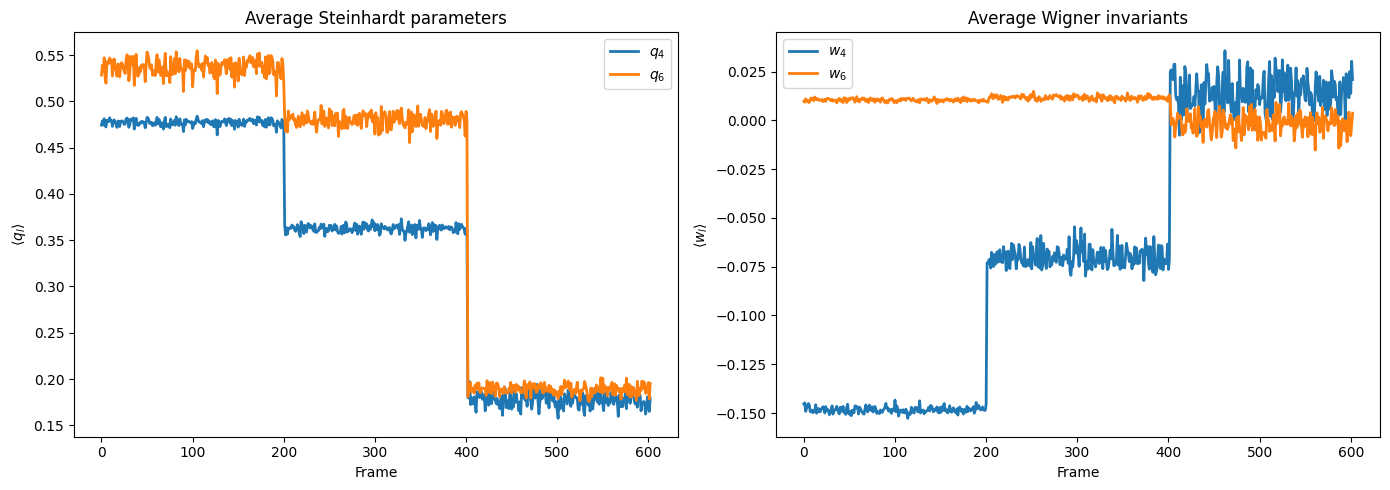

In [16]:
mean_desc = all_descriptors.mean(axis=1)
n_q = len(q_ls)
n_w = len(w_ls)
qvals = mean_desc[:, :n_q]
wvals = mean_desc[:, n_q:n_q + n_w]
frames = np.arange(len(mean_desc))

# --------------------------------------------------------
# Figure
# --------------------------------------------------------
fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 5)
)

# ========================================================
# q_l panel
# ========================================================
for i, l in enumerate(q_ls):

    axes[0].plot(
        frames,
        qvals[:, i],
        linewidth=2,
        label=rf"$q_{l}$"
    )

axes[0].set_xlabel("Frame")
axes[0].set_ylabel(r"$\langle q_l \rangle$")
axes[0].set_title("Average Steinhardt parameters")

axes[0].legend()

# ========================================================
# w_l panel
# ========================================================
for i, l in enumerate(w_ls):

    axes[1].plot(
        frames,
        wvals[:, i],
        linewidth=2,
        label=rf"$w_{l}$"
    )

axes[1].set_xlabel("Frame")
axes[1].set_ylabel(r"$\langle w_l \rangle$")
axes[1].set_title("Average Wigner invariants")

axes[1].legend()

# --------------------------------------------------------
# Final layout
# --------------------------------------------------------
plt.tight_layout()
plt.show()

In [17]:
# ============================================================
# Number of features
# ============================================================
n_features = len(q_ls) + len(w_ls)

print("\nNumber of features:")
print(n_features)


Number of features:
4


All the information associated with the dataset can now be collected into a metadata structure containing the most important details of the configurations and descriptor definitions.

This metadata will allow us to keep track of:
- the selected descriptors,
- the phase labels,
- the dataset organization,
- and the parameters used during the analysis.

We can then save the metadata together with the generated arrays so that the dataset is ready to be reused, shared, or analyzed in future sessions without recomputing the descriptors from scratch.

In [ ]:
# ============================================================
# Metadata
# ============================================================
feature_names = [
    *[f"q{l}" for l in q_ls],
    *[f"w{l}" for l in w_ls]
]

metadata = {
    # --------------------------------------------------------
    # Descriptor definitions
    # --------------------------------------------------------
    "q_ls": q_ls,
    "w_ls": w_ls,
    "feature_names": feature_names,
    "n_features": len(feature_names),

    # --------------------------------------------------------
    # Labels
    # --------------------------------------------------------
    "label_names": label_names,
    "n_labels": len(label_names),

    # --------------------------------------------------------
    # Dataset information
    # --------------------------------------------------------
    "datasets": datasets,

    # --------------------------------------------------------
    # Descriptor settings
    # --------------------------------------------------------
    "neighbor_method": "cutoff",
    "cutoff": 0,
    "averaged": True,
}

# ============================================================
# Print metadata
# ============================================================

print("Metadata:\n")

for key, value in metadata.items():

    print(f"{key}:")
    print(value)
    print()

Metadata:

q_ls:
[4, 6]

w_ls:
[4, 6]

feature_names:
['q4', 'q6', 'w4', 'w6']

n_features:
4

label_names:
{0: 'cubic', 1: 'hexagonal', 2: 'liquid'}

n_labels:
3

datasets:
{0: PosixPath('/Users/spears/Documents/Projects/MLinCP/data/mW/N256/0-cubic'), 1: PosixPath('/Users/spears/Documents/Projects/MLinCP/data/mW/N256/1-hexagonal'), 2: PosixPath('/Users/spears/Documents/Projects/MLinCP/data/mW/N256/2-liquid')}

neighbor_method:
cutoff

cutoff:
0

averaged:
True



In [ ]:
# ============================================================
# Save dataset
# ============================================================
np.savez_compressed(
    "mW_dataset.npz",
    descriptors=all_descriptors,
    labels=all_labels,
    positions=all_positions,
    boxes=all_boxes,
    metadata=metadata,
)

print("\nSaved dataset to:")
print("mW_dataset.npz")


Saved dataset to:
mW_dataset.npz


To load the dataset if needed later the following command will do the job:

```python
data = np.load("mW_dataset.npz", allow_pickle=True)

all_descriptors = data["descriptors"]
all_labels = data["labels"]
all_positions = data["positions"]
all_boxes = data["boxes"]

# Metadata is stored as an object array
# containing a Python dictionary
metadata = data["metadata"].item()
```

## 4. Deep Learning Environment

### Devices

Let us first check which computational resources are available on the current machine. The following cell automatically detects whether hardware accelerators such as CUDA-enabled GPUs or the Apple Metal backend (MPS) are available. If no accelerator is detected, the calculations will run on the CPU.

In [20]:
# ============================================================
# Device selection
# ============================================================

# CUDA: NVIDIA GPUs
if torch.cuda.is_available():

    device = torch.device("cuda")

    print("Using CUDA GPU")
    print(torch.cuda.get_device_name(0))

# MPS: Apple Silicon GPU (MacOS)
elif torch.backends.mps.is_available():

    device = torch.device("mps")

    print("Using Apple Silicon GPU (MPS)")

# CPU fallback
else:

    device = torch.device("cpu")

    print("Using CPU")

Using Apple Silicon GPU (MPS)


### PyTorch Tensors

Before building and training neural networks, we first need to convert our NumPy arrays into PyTorch tensors.

From the user perspective, PyTorch behaves in many ways similarly to NumPy:
- tensors support multidimensional arrays,
- most mathematical operations have a NumPy-like syntax,
- and tensors can be indexed and manipulated in very similar ways.

However, PyTorch introduces several important additional concepts that are essential for machine learning workflows.

The first key difference is that PyTorch works with **tensors** rather than NumPy arrays. Conceptually, tensors can be thought of as generalized multidimensional arrays that additionally carry information about:
- their datatype,
- and the device on which they are stored.

A second crucial concept is the idea of a **device**. A tensor can live either:
- on the CPU,
- or on an accelerator such as a GPU.

One of the main strengths of PyTorch is that the same code can often run transparently on different hardware simply by moving tensors and models to the appropriate device.

For example:

```python
device = torch.device("cuda")
```

runs computations on the processor.

On Apple Silicon systems, PyTorch can also make use of the Metal backend through:
```python
device = torch.device("mps")
```

An important rule is that operations can only be performed between tensors located on the same device. For example, adding:
- a tensor stored on the CPU,
- and a tensor stored on the GPU,
would generate an error.

For this reason, machine learning workflows typically begin by:
- selecting a device,
- moving all tensors to that device,
- and ensuring that the neural network itself is also allocated there.

Finally, unlike NumPy arrays, PyTorch tensors can also track operations for automatic differentiation, which is the mechanism used during neural network training to compute gradients and optimize model parameters.

<div class="alert alert-block alert-info">

**TASK**

3. Convert the descriptor arrays and labels from NumPy arrays to PyTorch tensors and move them to the selected computational device.

</div>

In [ ]:
# ============================================================
# Convert numpy arrays to torch tensors
# ============================================================

# Descriptors:
# (Nframes, Nparticles, Nfeatures)
X_tensor = # Your code goes here

# Labels:
# (Nframes, Nparticles)
y_tensor = # Your code goes here


# Positions:
# (Nframes, Nparticles, 3)
positions_tensor = # Your code goes here


# Boxes:
# (Nframes, 3)
boxes_tensor = # Your code goes here

# ============================================================
# Diagnostics
# ============================================================
print("\nTensor shapes:\n")

print("X_tensor:")
print(X_tensor.shape)
print(X_tensor.dtype)
print(X_tensor.device)

print()

print("y_tensor:")
print(y_tensor.shape)
print(y_tensor.dtype)
print(y_tensor.device)

print()

print("positions_tensor:")
print(positions_tensor.shape)

print()

print("boxes_tensor:")
print(boxes_tensor.shape)


Tensor shapes:

X_tensor:
torch.Size([603, 256, 4])
torch.float64
cpu

y_tensor:
torch.Size([603, 256])
torch.int64
cpu

positions_tensor:
torch.Size([603, 256, 3])

boxes_tensor:
torch.Size([603, 3])


## 5. Preparing the Datasets for Deep Learning

Before training the neural network, we need to divide the dataset into three independent subsets:
- a **training set**,
- a **validation set**,
- and a **test set**.

These subsets play different roles during the machine learning workflow.

The **training set** is the portion of the data used to optimize the parameters of the neural network through gradient descent.

The **validation set** is used during training to monitor the performance of the model on unseen data. This is important for:
- detecting overfitting,
- tuning hyperparameters,
- and implementing techniques such as early stopping or adaptive learning-rate scheduling.

Finally, the **test set** is kept completely separate during training and is used only at the end to estimate the final predictive performance of the model.

An important detail the split must be performed **by trajectory frame rather than by particle**.

This is crucial because particles belonging to the same molecular dynamics frame are strongly correlated. If particles from the same frame appeared simultaneously in both the training and test sets, the model could partially memorize structural information from the trajectory, leading to artificially optimistic results. This issue is commonly referred to as **data leakage** or, more specifically in this context, **trajectory leakage**.

To avoid this problem:
1. we first shuffle the trajectory frames,
2. then assign entire frames to either the training, validation, or test sets.

<div class="alert alert-block alert-info">

**TASK**

4. Split the dataset into training, validation, and test sets by randomly shuffling the trajectory frames while avoiding trajectory leakage between the different subsets. Choose reasonable fractions for the three sets and verify that the resulting partitions have the expected sizes.

</div>

In [ ]:
# ============================================================
# Split fractions
# ============================================================
train_fraction = # Your code goes here
validation_fraction = # Your code goes here
test_fraction = # Your code goes here

# ============================================================
# Number of frames
# ============================================================
n_frames = X_tensor.shape[0]

print("Number of frames:", n_frames)

# ============================================================
# Shuffle frames
# ============================================================
# IMPORTANT: we split by FRAME not by particle to avoid trajectory leakage
generator = torch.Generator(device="cpu")
generator.manual_seed(42)
frame_indices = # Your code goes here

# ============================================================
# Compute split sizes
# ============================================================
n_train = int(train_fraction * n_frames)
n_validation = int(validation_fraction * n_frames)
n_test = n_frames - n_train - n_validation

print("\nSplit sizes:\n")
print("Train      :", n_train)
print("Validation :", n_validation)
print("Test       :", n_test)

# ============================================================
# Split indices
# ============================================================
train_idx = # Your code goes here
validation_idx = # Your code goes here
test_idx =  # Your code goes here

# ============================================================
# Create splits
# ============================================================
# Shapes:
# (Nframes_split, Nparticles, Nfeatures)
X_train = X_tensor[train_idx]
X_validation = X_tensor[validation_idx]
X_test = X_tensor[test_idx]

# Shapes:
# (Nframes_split, Nparticles)
y_train = y_tensor[train_idx]
y_validation = y_tensor[validation_idx]
y_test = y_tensor[test_idx]

# ============================================================
# Diagnostics
# ============================================================
print("\nTensor split shapes:\n")
print("X_train:")
print(X_train.shape)
print()
print("X_validation:")
print(X_validation.shape)
print()
print("X_test:")
print(X_test.shape)
print()
print("y_train:")
print(y_train.shape)
print()
print("y_validation:")
print(y_validation.shape)
print()
print("y_test:")
print(y_test.shape)

At this stage, the descriptor tensors still retain the original trajectory structure:

$$
(N_{\mathrm{frames}},\ N_{\mathrm{particles}},\ N_{\mathrm{features}})
$$

This organization is convenient for physical analysis because it preserves the information about:
- which particles belong to a given frame,
- and which frames belong to a given trajectory.

However, for the supervised learning task considered here, the neural network will classify the local environment of particles independently. From the perspective of the model, each particle therefore corresponds to one training example described by:
- a vector of structural descriptors,
- and an associated label.

For this reason, before training the neural network we flatten the dataset by combining the frame and particle dimensions into a single dimension. The descriptor tensor is therefore reshaped into:

$$
(N_{\mathrm{samples}},\ N_{\mathrm{features}})
$$

where:

$$
N_{\mathrm{samples}}
=
N_{\mathrm{frames}}
\times
N_{\mathrm{particles}}.
$$

Similarly, the label tensor is reshaped into a one-dimensional vector containing one class label per particle.

Once flattened, the tensors can be wrapped into a `TensorDataset`, a PyTorch utility class that groups together:
- input tensors,
- target labels,
- and potentially additional quantities.

This provides a convenient interface for building data loaders and iterating over mini-batches during training.

<div class="alert alert-block alert-info">

**TASK**

5. Flatten the descriptor and label tensors by combining the frame and particle dimensions into a single sample dimension. Then construct PyTorch `TensorDataset` objects for the training, validation, and test sets.

</div>

In [ ]:
from torch.utils.data import TensorDataset

# ============================================================
# Number of features
# ============================================================
# n_features = X_tensor.shape[-1]

# ============================================================
# Flatten datasets
# ============================================================
# From:
# (Nframes, Nparticles, Nfeatures)
# To:
# (Nsamples, Nfeatures)
X_train_flat =  # Your code goes here
X_validation_flat =  # Your code goes here
X_test_flat =  # Your code goes here

# From:
# (Nframes, Nparticles)
# To:
# (Nsamples,)
y_train_flat =  # Your code goes here
y_validation_flat =  # Your code goes here
y_test_flat =  # Your code goes here

# ============================================================
# Diagnostics
# ============================================================
print("Flattened datasets:\n")
print("X_train_flat:")
print(X_train_flat.shape)
print()
print("X_validation_flat:")
print(X_validation_flat.shape)
print()
print("X_test_flat:")
print(X_test_flat.shape)
print()
print("y_train_flat:")
print(y_train_flat.shape)
print()
print("y_validation_flat:")
print(y_validation_flat.shape)
print()
print("y_test_flat:")
print(y_test_flat.shape)

# ============================================================
# Torch datasets
# ============================================================
train_dataset = # Your code goes here
validation_dataset =  # Your code goes here
test_dataset =  # Your code goes here

# ============================================================
# Dataset sizes
# ============================================================
print("\nTorch datasets:\n")
print("Training samples:")
print(len(train_dataset))
print()
print("Validation samples:")
print(len(validation_dataset))
print()
print("Test samples:")
print(len(test_dataset))

Flattened datasets:

X_train_flat:
(92416, 4)

X_validation_flat:
(30976, 4)

X_test_flat:
(30976, 4)

y_train_flat:
torch.Size([92416])

y_validation_flat:
torch.Size([30976])

y_test_flat:
torch.Size([30976])

Torch datasets:

Training samples:
92416

Validation samples:
30976

Test samples:
30976


/var/folders/96/hkk5jp994_32fyjh9vc18j6r0000gn/T/ipykernel_11410/455495019.py:52: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_dataset = TensorDataset(torch.tensor(X_train_flat, dtype=torch.float32), torch.tensor(y_train_flat, dtype=torch.float32))
/var/folders/96/hkk5jp994_32fyjh9vc18j6r0000gn/T/ipykernel_11410/455495019.py:53: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  validation_dataset = TensorDataset(torch.tensor(X_validation_flat, dtype=torch.float32), torch.tensor(y_validation_flat, dtype=torch.float32))
/var/folders/96/hkk5jp994_32fyjh9vc18j6r0000gn/T/ipykernel_11410/455495019.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clo

## 6. Feed-Forward Neural Network

We now implement the neural network architecture that will be used for the structural classification task.

The goal is to construct a flexible feed-forward neural network (FFNN) that can adapt to different architectures without modifying the internal implementation of the class. In particular, the network should allow the user to:
- choose the number of hidden layers,
- specify the number of neurons in each hidden layer,
- select the [activation function](https://docs.pytorch.org/docs/main/nn.html),
- optionally include [dropout layers](https://docs.pytorch.org/docs/2.11/generated/torch.nn.Dropout.html),
- and optionally include [batch-normalization layers](https://docs.pytorch.org/docs/2.11/generated/torch.nn.BatchNorm1d.html).

Internally, the model will dynamically construct a list of layers based on the user-provided architecture. These layers will then be combined using `torch.nn.Sequential` (check [docs](https://docs.pytorch.org/docs/2.11/generated/torch.nn.Sequential.html)), which automatically applies them in sequence during the forward pass.

Recall that a feed-forward neural network is built from repeated blocks of:
- linear transformations,
- nonlinear activation functions,
- and optional regularization layers such as dropout or batch normalization.

For **hidden layers**, the recommended ordering is:

$$
\text{Linear}
\rightarrow
\text{BatchNorm}
\rightarrow
\text{Activation}
\rightarrow
\text{Dropout}.
$$

The **output layer** should instead contain only a linear transformation producing the final logits (raw outputs of the neural network) associated with the different structural classes.

<div class="alert alert-block alert-info">

**TASK**

6. Complete the implementation of the `FeedForwardNN` class by dynamically constructing the neural network architecture from the provided list of hidden-layer dimensions. Include optional support for:
- dropout,
- customizable activation functions,
- and batch-normalization layers.

</div>

In [ ]:
# ============================================================
# Feed Forward Neural Network
# ============================================================

class FeedForwardNN(nn.Module):

    def __init__(
        self,
        input_dim,
        output_dim,
        hidden_dims=None,
        dropout=0.0,
        activation=nn.ReLU,
        batch_norm=False
    ):
        """
        Parameters
        ----------
        input_dim : int
            Number of input features.

        output_dim : int
            Number of output classes.

        hidden_dims : list[int] or None
            Hidden layer sizes.

            Example:
            [64, 128, 64]

            If None:
            direct linear mapping input -> output.

        dropout : float
            Dropout probability.

        activation : torch.nn.Module
            Activation function class.

            Examples:
            nn.ReLU
            nn.Tanh
            nn.LeakyReLU

        batch_norm : bool
            If True, add BatchNorm1d layers
            after each hidden linear layer.
        """
        super().__init__()

        # ----------------------------------------------------
        # Default: no hidden layers
        # ----------------------------------------------------
        if hidden_dims is None:
            hidden_dims = []

        # ----------------------------------------------------
        # Build layer dimensions
        # ----------------------------------------------------
        # Example:
        # [input, 64, 128, output]

        layer_dims = # Your code goes here

        # ----------------------------------------------------
        # Build network dynamically
        # ----------------------------------------------------
        layers = []
        for i in range(len(layer_dims) - 1):
            in_dim =  # Your code goes here
            out_dim =  # Your code goes here

            # --------------------------------------------
            # Linear layer
            # --------------------------------------------
            layers.append( # Your code goes here )

            # --------------------------------------------
            # Hidden layers only
            # --------------------------------------------
            is_last_layer = (
                i == len(layer_dims) - 2
            )

            if not is_last_layer:

                # ----------------------------------------
                # Batch normalization
                # ----------------------------------------
                if batch_norm:
                    # Your code goes here

                # ----------------------------------------
                # Activation
                # ----------------------------------------
                layers.append( # Your code goes here )

                # ----------------------------------------
                # Dropout
                # ----------------------------------------
                if dropout > 0:
                    # Your code goes here


        # ----------------------------------------------------
        # Sequential model
        # ----------------------------------------------------
        self.network = nn.Sequential(

            *layers
        )

    # ========================================================
    # Forward pass
    # ========================================================
    def forward(self, x):

        return self.network(x)

We now instantiate the neural network model that will be trained for the structural classification task.

Once the number of classes (cubic, hexagonal, etc.) has been determined, the neural network is then constructed by creating an instance of the `FeedForwardNN` class:
```python
model = FeedForwardNN(
    input_dim=n_features,
    output_dim=n_classes,
    hidden_dims=[16, 16],
    dropout=0.1
)
```
Here:
- input_dim is the number of structural descriptors associated with each particle,
- output_dim is the number of target classes,
- and `hidden_dims=[16,16]` specifies a network with two hidden layers containing 16 neurons each.

A dropout probability of $0.1$ is also included as a regularization mechanism to reduce overfitting during training.

The model is then moved to the selected computational device and some information is printed.

In [ ]:
# ============================================================
# Number of classes
# ============================================================
n_classes = len(label_names)
print("Number of classes:", n_classes)

# ============================================================
# Build model
# ============================================================
model = FeedForwardNN(
    input_dim=n_features,
    output_dim=n_classes,
    hidden_dims=[16, 16],
    dropout=0.1
)

# ============================================================
# Move model to device
# ============================================================
model = model.to(device)

# ============================================================
# Diagnostics
# ============================================================
print(model)

print("\nModel device:")
print(next(model.parameters()).device)

# ============================================================
# Number of trainable parameters
# ============================================================
n_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("\nNumber of trainable parameters:")
print(f"{n_parameters}")

<div class="alert alert-block alert-info">

**TASK**

7. Define the loss function that will be used to optimize the neural network during training. You may either:
- implement your own criterion,
- or use one of the loss modules already available in PyTorch through `torch.nn`.

For this classification problem, the most relevant choices are:
- `nn.MSELoss` (see [here](https://docs.pytorch.org/docs/2.11/generated/torch.nn.MSELoss.html)),
- and `nn.CrossEntropyLoss` (see [here](https://docs.pytorch.org/docs/2.11/generated/torch.nn.CrossEntropyLoss.html)).

Experiment with both and compare their behavior during training.

Recall that:
- `MSELoss` compares predictions and targets through a squared-error metric,
- while `CrossEntropyLoss` is specifically designed for multi-class classification problems and operates directly on the network logits.

</div>

In [ ]:
# ============================================================
# Loss function
# ============================================================

# CrossEntropyLoss expects:
#
# logits:
# (batch_size, n_classes)
#
# labels:
# (batch_size,)
#
# with integer class labels

criterion =  # Your code goes here

# ============================================================
# Diagnostics
# ============================================================

print("Loss function:")
print(criterion)

<div class="alert alert-block alert-info">

**TASK**

8. Set up the optimizer that will be used to update the neural network parameters during training. Use the parameters returned by:

```python
model.parameters()
```

For this workshop, we recommended the use of Adam, available through [torch.optim.Adam](https://docs.pytorch.org/docs/2.11/generated/torch.optim.Adam.html#torch.optim.Adam).

Then implement a learning-rate scheduler to automatically reduce the learning rate when the validation loss stops improving. In particular, use the [ReduceLROnPlateau](https://docs.pytorch.org/docs/2.11/generated/torch.optim.lr_scheduler.ReduceLROnPlateau.html#torch.optim.lr_scheduler.ReduceLROnPlateau) scheduler from torch.optim.lr_scheduler.

</div>

In [ ]:
import torch.optim as optim

# ============================================================
# Optimizer
# ============================================================
learning_rate = 1e-3
weight_decay = 1e-5 # Optional, check docs

optimizer = # Your code goes here

# ============================================================
# Learning rate scheduler
# ============================================================
# Reduce learning rate when
# validation loss plateaus
scheduler =  # Your code goes here

# ============================================================
# Diagnostics
# ============================================================
print("Optimizer:\n")
print(optimizer)
print("\nScheduler:\n")
print(scheduler)

## 7. The Training Routine

We are now ready to train the neural network.

### DataLoader

Training a neural network consists of iteratively updating the model parameters in order to minimize the chosen loss function on the training dataset. In practice, this process is performed over many **epochs**, where one epoch corresponds to one complete pass through the training dataset.

Because the dataset can become large, it is inefficient to process all samples simultaneously. Instead, PyTorch uses the `DataLoader` class (see [here](https://docs.pytorch.org/docs/2.11/data.html#torch.utils.data.DataLoader)) to divide the dataset into smaller subsets called **mini-batches**.

A `DataLoader`:
- iterates automatically over the dataset,
- groups samples into batches,
- optionally shuffles the data,
- and efficiently transfers batches during training.

For the training set we typically enable:

```python
shuffle=True
```

to randomize the order of the samples at every epoch. This helps prevent the network from learning spurious ordering correlations.

The validation set instead is usually evaluated with:
```python
shuffle=False
```
since no parameter updates are performed during validation.

### Training Phase

Each training epoch is divided into two distinct phases:

- a training phase,
- and a validation phase.

During the training phase:

1. the model is placed in training mode through:
```python
model.train()
```
2. mini-batches are loaded from the training DataLoader,
3. predictions are computed through a forward pass,
4. the loss is evaluated,
5. gradients are computed through backpropagation,
6. and the optimizer updates the network parameters.

The key operations are:
```python
optimizer.zero_grad()
```
which resets the gradients accumulated from previous batches,
```python
logits = model(X_batch)
```
which performs the forward pass through the network,
```python
loss.backward()
```
which computes the gradients of the loss with respect to all trainable parameters, and finally:
```python
optimizer.step()
```
which updates the parameters according to the optimizer rule.

At the same time, we accumulate statistics such as:

- the running loss,
- and the prediction accuracy.

Predicted classes are obtained from the logits using:
```python
predictions = torch.argmax(logits, dim=1)
```
which selects the class associated with the largest logit value.

### Validation Phase

During the validation phase:

1. the model is switched to evaluation mode through:
```python
model.eval()
```

This is particularly important when using:

- dropout,
- batch normalization,
- or other layers with training-dependent behavior.

Validation is performed inside:

```python
with torch.no_grad():
```

which disables gradient tracking. Since no optimization is performed during validation, this:

- reduces memory usage,
- accelerates computations,
- and prevents accidental parameter updates.

The validation phase computes the same metrics as the training phase, but on data that was not used to optimize the model.

### Learning Rate Scheduler

During training, the optimization process may eventually plateau. To improve convergence, we use a learning-rate scheduler.

In this notebook we recommended the use of `ReduceLROnPlateau` which monitors the validation loss and automatically reduces the learning rate whenever the validation performance stops improving.

The scheduler is updated after every validation phase through:

```python
scheduler.step(epoch_validation_loss)
```

This allows the optimization process to progressively take smaller steps as training converges.

### Early Stopping

A neural network can eventually start overfitting the training data, meaning that:

- the training loss continues decreasing,
- while the validation performance stops improving or worsens.

To avoid unnecessary training and reduce overfitting, we implement early stopping.

The idea is simple:

- after every epoch we monitor the validation loss,
- if the validation loss improves, we reset a counter,
- otherwise we increment the counter,
- and if no improvement is observed for a predefined number of epochs (the patience), training is interrupted.

This provides:

- faster training,
- reduced overfitting,
- and automatic selection of the best-performing model.

### Bonus: Notebook Interruption Handling

Since training can sometimes take a long time, especially when experimenting with different architectures, the training loop is wrapped inside:

```python
try:
    ...
except KeyboardInterrupt:
```

This allows the notebook to terminate training gracefully if the user interrupts execution manually, without losing the current model state or training history.

<div class="alert alert-block alert-info">

**TASK**

9. Complete the implementation of the training loop by:
- iterating over mini-batches using the PyTorch DataLoader,
- implementing the forward and backward passes,
- computing training and validation metrics,
- updating the optimizer,
- stepping the learning-rate scheduler using the validation loss,
- and implementing an early-stopping criterion based on the validation loss.

</div>

In [ ]:
from torch.utils.data import DataLoader
import copy
import os 
import time

# ============================================================
# DataLoaders
# ============================================================
batch_size = 256

train_loader =  # Your code goes here

validation_loader =  # Your code goes here

# ============================================================
# Training parameters
# ============================================================
n_epochs = 200

# ============================================================
# Model directory
# ============================================================
model_dir = "saved_models"

os.makedirs(
    model_dir,
    exist_ok=True
)

# ============================================================
# Model paths
# ============================================================

best_model_path = os.path.join(
    model_dir,
    "best_model.pt"
)

last_model_path = os.path.join(
    model_dir,
    "last_model.pt"
)

# ============================================================
# Early stopping
# ============================================================
early_stopping_patience = 20
best_validation_loss = float("inf")
epochs_without_improvement = 0
best_model_state = None

# ============================================================
# History
# ============================================================
train_losses = []
validation_losses = []
train_accuracies = []
validation_accuracies = []

# ============================================================
# Training loop
# ============================================================
try:

    for epoch in range(n_epochs):

        epoch_start_time = time.perf_counter()

        # ====================================================
        # Training phase
        # ====================================================
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for X_batch, y_batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{n_epochs} [Train]", leave=False):

            # ------------------------------------------------
            # Zero gradients
            # ------------------------------------------------
            # Your code goes here

            # ------------------------------------------------
            # Forward pass
            # ------------------------------------------------
            # Your code goes here

            # ------------------------------------------------
            # Backpropagation
            # ------------------------------------------------
             # Your code goes here

            # ------------------------------------------------
            # Statistics
            # ------------------------------------------------
            running_loss +=  # Your code goes here
            predictions =  # Your code goes here
            correct +=  # Your code goes here
            total +=  # Your code goes here

        # ====================================================
        # Training metrics
        # ====================================================
        epoch_train_loss = running_loss / total
        epoch_train_accuracy = correct / total
        train_losses.append(epoch_train_loss)
        train_accuracies.append(epoch_train_accuracy)

        # ====================================================
        # Validation phase
        # ====================================================
        model.eval()

        running_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():

            for X_batch, y_batch in validation_loader:

                # --------------------------------------------
                # Forward pass
                # --------------------------------------------
                # Your code goes here

                # --------------------------------------------
                # Statistics
                # --------------------------------------------
                running_loss +=  # Your code goes here
                predictions =  # Your code goes here
                correct +=  # Your code goes here
                total +=  # Your code goes here

        # ====================================================
        # Validation metrics
        # ====================================================
        epoch_validation_loss = running_loss / total
        epoch_validation_accuracy = correct / total
        validation_losses.append(epoch_validation_loss)
        validation_accuracies.append(epoch_validation_accuracy)

        # ====================================================
        # Scheduler step
        # ====================================================
        # Your code goes here

        # ====================================================
        # Current learning rate
        # ====================================================
        current_lr = optimizer.param_groups[0]["lr"]

        # ====================================================
        # Early stopping
        # ====================================================
        if epoch_validation_loss < best_validation_loss:
            
            # !!!!!!!!!!!!!!!!!!!
            # Your code goes here
            # !!!!!!!!!!!!!!!!!!!

            # Save best model state in memory
            best_model_state =  # Your code goes here

            # Save best model to disk
            torch.save(
                {
                    "epoch": epoch + 1,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "scheduler_state_dict": scheduler.state_dict(),
                    "validation_loss": epoch_validation_loss,
                    "metadata": metadata,
                    "n_features": n_features,
                    "n_classes": n_classes,
                    "label_names": label_names,
                    "feature_names": feature_names,
                },
                best_model_path
            )

        else:

            # Your code goes here
            
        # ====================================================
        # Save last model
        # ====================================================
        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "validation_loss": epoch_validation_loss,
                "metadata": metadata,
                "n_features": n_features,
                "n_classes": n_classes,
                "label_names": label_names,
                "feature_names": feature_names,
            },
            last_model_path
        )
        
        # ====================================================
        # Epoch summary
        # ====================================================
        epoch_end_time = time.perf_counter()
        epoch_time = epoch_end_time - epoch_start_time
        remaining_time = (n_epochs - epoch - 1) * epoch_time
        
        print(
            f"Epoch {epoch+1:3d}/{n_epochs} | "
            f"Train Loss: {epoch_train_loss:.5f} | "
            f"Train Acc: {epoch_train_accuracy:.5f} | "
            f"Val Loss: {epoch_validation_loss:.5f} | "
            f"Val Acc: {epoch_validation_accuracy:.5f} | "
            f"LR: {current_lr:.2e} | "
            f"Time: {epoch_time:.2f} s | "
            f"ETA: {remaining_time/60:.1f} min"
        )

        # ====================================================
        # Stop training
        # ====================================================
        if epochs_without_improvement >= early_stopping_patience:

            print("\nEarly stopping triggered.")
            break

# ============================================================
# Catch notebook interruption
# ============================================================
except KeyboardInterrupt:

    print("\nTraining interrupted by user.")


# ============================================================
# Restore best model
# ============================================================
if best_model_state is not None:

    model.load_state_dict(best_model_state)

    print("\nBest model restored.")
    print(f"Best validation loss: {best_validation_loss:.5f}")

In the next cell we provide a template for visualizing the training metrics accumulated during optimization, with particular focus on:
- the training and validation loss,
- and the training and validation accuracy.

These plots are extremely important for diagnosing the behavior of the neural network during training and for identifying issues such as overfitting or underfitting.

In [ ]:
# ============================================================
# Number of completed epochs
# ============================================================
n_completed_epochs = len(train_losses)
epochs = np.arange(1, n_completed_epochs + 1)

# ============================================================
# Figure
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ============================================================
# Losses
# ============================================================
# Train
axes[0].plot(
    epochs,
    train_losses,
    linewidth=2,
    label="Training"
)

#Eval
axes[0].plot(
    epochs,
    validation_losses,
    linewidth=2,
    label="Validation"
)

# Best validation epoch
best_epoch = np.argmin(validation_losses) + 1
axes[0].axvline(
    best_epoch,
    linestyle="--",
    linewidth=2,
    label="Best model"
)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training and validation loss")
axes[0].legend()
axes[0].grid(True)

# ============================================================
# Accuracies
# ============================================================
# Train
axes[1].plot(
    epochs,
    train_accuracies,
    linewidth=2,
    label="Training"
)

#Eval
axes[1].plot(
    epochs,
    validation_accuracies,
    linewidth=2,
    label="Validation"
)

# Best validation epoch
axes[1].axvline(
    best_epoch,
    linestyle="--",
    linewidth=2,
    label="Best model"
)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Training and validation accuracy")
axes[1].legend()
axes[1].grid(True)

# ============================================================
# Final layout
# ============================================================
plt.tight_layout()
plt.show()

## 8. Evaluating Model Performances

Once training is complete, the final step is to evaluate the performance of the neural network on the test dataset.

Recall that the test set was never used:
- during training,
- nor during validation.

It therefore provides an unbiased estimate of the predictive performance of the model on previously unseen data.

As during validation, evaluation is performed in inference mode by calling:

```python
model.eval()
```

and by disabling gradient computations through:

```python
with torch.no_grad():
```

Since no optimization is performed during testing:

- gradients are unnecessary,
- memory consumption is reduced,
- and computations become faster.

The test loop closely resembles the validation loop:
- mini-batches are loaded from the test DataLoader,
- the model performs a forward pass,
- the loss is evaluated,
- predictions are extracted from the logits,
- and predictions and targets are stored for later analysis.

Predicted classes are obtained through:
```python
predictions = torch.argmax(logits, dim=1)
```
which selects the class associated with the largest output logit.

After processing all batches:
- the predictions and targets are concatenated,
- moved to the CPU,
- and converted to NumPy arrays in order to interface with the analysis tools provided by scikit-learn, namely `confusion_matrix` (see [here](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)), `classification_report` (see [here](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)) and `accuracy_score` (see [here](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html)).

### Accuracy Score

The simplest evaluation metric is the accuracy:

$$
\text{Accuracy} =\frac{\text{Number of correct predictions}}{\text{Total number of predictions}}
$$

This metric is computed using:
```python
accuracy_score(y_true, y_pred)
```

and measures the overall fraction of correctly classified particles.

### Classification Report

The function:

```python
classification_report(...)
```
provides a more detailed analysis of the classification performance for each class individually.

In particular, it reports:

- precision,
- recall,
- F1-score,
- and support.

For a given class:

- **precision** measures how many predicted samples of that class are actually correct,
- **recall** measures how many samples belonging to that class were successfully identified,
- while the **F1-score** combines both quantities into a single metric.

This is especially useful when:

- some classes are more difficult to classify,
- or when the dataset is imbalanced.

### Confusion Matrix

A very important diagnostic tool is the confusion matrix, computed through:

```python
confusion_matrix(y_true, y_pred)
```

The confusion matrix is a square matrix in which:

- rows correspond to the true labels,
- columns correspond to the predicted labels.

Each element $C_{ij}$ represents the number of samples:

- belonging to class $i$,
- but predicted as class $j$.

The diagonal elements therefore correspond to correct classifications, while off-diagonal elements identify the types of mistakes made by the model.

For structural classification problems such as this one, the confusion matrix is extremely informative because it allows us to identify:

- which phases are easily recognized,
- which phases are confused with each other,
- and whether the model struggles near structural interfaces or defective regions.

<div class="alert alert-block alert-info">

**TASK**

10. Complete the implementation of the test loop by:
    - iterating over the test DataLoader,
    - performing the forward pass,
    - computing the test loss,
    - extracting predictions from the logits,
    - and storing predictions and targets for later analysis.

</div>

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score


# ============================================================
# Test DataLoader
# ============================================================
test_loader = # Your code goes here

# ============================================================
# Evaluation mode
# ============================================================
model.eval()

# ============================================================
# Storage
# ============================================================
all_predictions = []
all_targets = []
test_loss = 0.0
total = 0

# ============================================================
# Test loop
# ============================================================
with torch.no_grad():

    for X_batch, y_batch in test_loader:

        # ----------------------------------------------------
        # Forward pass
        # ----------------------------------------------------
        # Your code goes here

        # ----------------------------------------------------
        # Statistics
        # ----------------------------------------------------
        # Your code goes here

        # ----------------------------------------------------
        # Predictions
        # ----------------------------------------------------
        # Your code goes here

        # ----------------------------------------------------
        # Store
        # ----------------------------------------------------
        # Your code goes here

# ============================================================
# Concatenate tensors
# ============================================================
all_predictions = torch.cat(all_predictions)
all_targets = torch.cat(all_targets)

# ============================================================
# Convert to numpy
# ============================================================
y_pred = all_predictions.numpy()
y_true = all_targets.numpy()

# ============================================================
# Metrics
# ============================================================
test_loss /= total
test_accuracy = accuracy_score(
    y_true,
    y_pred
)

# ============================================================
# Print metrics
# ============================================================
print("Test results:\n")
print(f"Test loss     : {test_loss:.5f}")
print(f"Test accuracy : {test_accuracy:.5f}")

# ============================================================
# Classification report
# ============================================================
target_names = [
    label_names[i]
    for i in sorted(label_names.keys())
]

print("\nClassification report:\n")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=target_names
    )
)

# ============================================================
# Confusion matrix
# ============================================================
cm = confusion_matrix(
    y_true,
    y_pred
)

print("\nConfusion matrix:\n")
print(cm)

### Normalized Confusion Matrix

While the raw confusion matrix contains the absolute number of predictions in each category, it is often more informative to visualize a **normalized confusion matrix**.

In a normalized confusion matrix, each row is divided by the total number of samples belonging to the corresponding true class. The matrix elements therefore represent fractions or probabilities rather than absolute counts.

More specifically, the element $\tilde{C}_{ij}$ corresponds to the fraction of samples:
- truly belonging to class $i$,
- that are predicted as class $j$.

With this normalization:
- diagonal elements close to 1 indicate accurate classification,
- while large off-diagonal elements reveal systematic confusion between different phases.

Normalized confusion matrices are particularly useful when:
- classes contain different numbers of samples,
- or when comparing classification performance across multiple categories.

In the following cell we visualize the normalized confusion matrix as a heatmap in order to obtain a more intuitive picture of the strengths and weaknesses of the classifier.

In [ ]:
# ============================================================
# Normalize confusion matrix
# ============================================================
cm_normalized = (cm.astype(float) / cm.sum(axis=1, keepdims=True))

# ============================================================
# Figure
# ============================================================

fig, ax = plt.subplots(figsize=(7, 6))

# ============================================================
# Heatmap
# ============================================================
im = ax.imshow(
    cm_normalized,
    interpolation="nearest",
    cmap="magma"
)

# ============================================================
# Colorbar
# ============================================================
cbar = plt.colorbar(im)
cbar.set_label("Normalized counts")

# ============================================================
# Ticks and labels
# ============================================================
ax.set_xticks(np.arange(len(target_names)))
ax.set_yticks(np.arange(len(target_names)))
ax.set_xticklabels(target_names)
ax.set_yticklabels(target_names)

# ============================================================
# Axis labels
# ============================================================
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Normalized confusion matrix")

# ============================================================
# Rotate x labels
# ============================================================
plt.setp(
    ax.get_xticklabels(),
    rotation=45,
    ha="right",
    rotation_mode="anchor"
)

# ============================================================
# Annotate cells
# ============================================================
threshold = cm_normalized.max() / 2

for i in range(cm_normalized.shape[0]):
    for j in range(cm_normalized.shape[1]):

        ax.text(
            j,
            i,
            f"{cm_normalized[i, j]:.2f}",
            ha="center",
            va="center",
            color="white" if cm_normalized[i, j] < threshold else "black"
        )


# ============================================================
# Final layout
# ============================================================
plt.tight_layout()
plt.show()

## 10. Homework Assignment: Structural Analysis of a Nucleation Trajectory

In this assignment you will apply the trained neural network to analyze a previously unseen molecular dynamics trajectory corresponding to a spontaneous nucleation event.

The trajectory is located in `/data/mW/N256/4-nucleating`.

Your goal is to classify the local structural environment of each particle throughout the nucleation process and visualize the evolution of the crystalline nucleus.

To accomplish this, you will need to repeat the full data-processing workflow developed in this notebook, excluding the training stage. 

<div class="alert alert-block alert-info">

In particular, you should:
1. Load the nucleating trajectory using MDAnalysis.
2. Compute the structural descriptors for every particle and frame using pyscal.
3. Convert the descriptors into PyTorch tensors.
4. Run the trained neural network in inference mode on the new trajectory.
5. Store the predictions inside the corresponding ASE Atoms objects.
</div>

The notebook already provides example code for:
- storing predictions and probabilities inside ASE objects,
- and visualizing trajectories using `WeasWidget`.

As a first analysis, visualize the trajectory by coloring particles according to:
- the predicted class,
- and the probability of belonging to the solid phase.

Recall that the network outputs logits. To convert these logits into probabilities, apply the softmax function:
$$
p_i = \frac{\exp[\hat{y}_i]}{\sum_j\exp[\hat{y}_j]}
$$

where:
- $\hat{y}_i$ are the logits,
- and $p_i$ are the corresponding class probabilities.

You can then store:
- the predicted class obtained through argmax,
- and the individual class probabilities,
inside the ASE trajectory frames and use them directly within `WeasWidget`.

Try to identify:
- the emergence of crystalline nuclei,
- interfaces between phases,
- and regions with uncertain classification.


In [ ]:
# ============================================================
# Input trajectory
# ============================================================
u = # Your code goes here

# ============================================================
# Storage
# ============================================================
trajectory_frames = []

# ============================================================
# Evaluation mode
# ============================================================
model.eval()

# ============================================================
# Loop over trajectory
# ============================================================
for iframe, ts in enumerate(tqdm(u.trajectory[::frame_stride], desc="Analyzing trajectory")):

    # --------------------------------------------------------
    # Coordinates and box
    # --------------------------------------------------------
    # Your code goes here

    # --------------------------------------------------------
    # ASE atoms object
    # --------------------------------------------------------
    # Your code goes here

    # --------------------------------------------------------
    # Neighbor finding
    # --------------------------------------------------------
    # Your code goes here

    # --------------------------------------------------------
    # q_l descriptors
    # --------------------------------------------------------
    # Your code goes here

    # --------------------------------------------------------
    # w_l descriptors
    # --------------------------------------------------------
    # Your code goes here

    # --------------------------------------------------------
    # Descriptor matrix
    # --------------------------------------------------------
    descriptors = # Your code goes here

    # --------------------------------------------------------
    # Torch tensor
    # --------------------------------------------------------
    X_frame = # Your code goes here

    # --------------------------------------------------------
    # Model prediction
    # --------------------------------------------------------
    # Your code goes here

    # --------------------------------------------------------
    # Move to CPU / numpy
    # --------------------------------------------------------
    probabilities = probabilities.cpu().numpy()
    predictions = predictions.cpu().numpy()

    # --------------------------------------------------------
    # Store particle properties
    # --------------------------------------------------------

    # Integer predicted class
    ase_atoms.arrays["prediction"] = predictions

    # Class probabilities
    for iclass in range(n_classes):
        ase_atoms.arrays[f"p{iclass}"] = probabilities[:, iclass]

    # Solid probability
    #
    # Assuming:
    # 0 -> cubic
    # 1 -> hexagonal
    # 2 -> liquid
    # 3 -> amorphous
    ase_atoms.arrays["p_solid"] = (probabilities[:, 0] + probabilities[:, 1])
    
    # --------------------------------------------------------
    # Store frame
    # --------------------------------------------------------
    trajectory_frames.append(ase_atoms)

print("\nTrajectory loaded.")
print(f"Number of frames: {len(trajectory_frames)}")

### Visualizing the Nucleation Trajectory

We now visualize the molecular dynamics trajectory together with the predictions generated by the neural network.

The trajectory is displayed using `WeasWidget`, an interactive visualization tool capable of rendering ASE trajectory objects directly inside the notebook.

In the previous steps, the predicted structural labels and probabilities were stored inside the ASE `Atoms` objects as additional per-particle arrays. These quantities can now be used to color particles dynamically during visualization.

The visualization mode is controlled through the variable:

```python
visualization_mode = ...
```

Different modes allow us to inspect different aspects of the neural-network predictions.

#### Discrete Structural Classification
The mode:
```python
visualization_mode = "prediction"
```
colors particles according to the predicted structural class:
- cubic ice,
- hexagonal ice,
- or liquid water.

This is useful for identifying:
- crystalline domains,
- stacking disorder,
- interfaces between phases,
- and the local symmetry of growing nuclei.

The corresponding color scheme is:
- blue → cubic,
- red → hexagonal,
- gray → liquid.

#### Binary Solid/Liquid Classification

The mode:
```python
visualization_mode = "solid_liquid"
```
reduces the classification problem to a simpler binary distinction:
- liquid,
- or solid.
Internally, all non-liquid predictions are grouped into a single “solid” category.
This representation is often the easiest way to visualize the emergence and growth of a crystalline nucleus during nucleation.
The color scheme is:
- blue → liquid,
- red → solid.

#### Probability Visualization
The neural network does not only produce discrete predictions. The output logits can also be converted into probabilities using the softmax function.
The following modes visualize these probabilities directly:

- "p_solid" → probability that a particle belongs to the solid phase,
- "p0" → probability of cubic ice,
- "p1" → probability of hexagonal ice,
- "p2" → probability of liquid water.

These representations are particularly informative near:
- interfaces,
- defects,
- and partially ordered regions,

where the network may be uncertain about the classification.
In these modes, particles are colored using a continuous color scale:

- dark blue → very low probability,
- light blue → low probability,
- yellow → high probability,
- red → very high probability.

Probability visualizations often reveal precursor structures and fluctuating local order that may not yet appear clearly in the discrete classification.

#### Interactive Exploration
The widget allows interactive exploration of the trajectory:
- rotating the system,
- zooming,
- translating the view,
- and scrolling through frames.

By switching between the different visualization modes, it is possible to investigate:
- how crystalline nuclei emerge,
- how local environments evolve,
- and how confident the neural network is in its predictions throughout the nucleation process.


> **Important note:**  
> 
> Due to the current behavior of `WeasWidget`, particle colors are updated correctly only when the trajectory frames are changed manually using the frame slider at the bottom of the widget. If the trajectory is played automatically using the play button, the atomic positions are updated but the colors associated with the predictions or probabilities may not refresh correctly.

In [ ]:
from weas_widget import WeasWidget

# ============================================================
# Visualization mode
# ============================================================

# Available modes:
# "solid_liquid" is the particle solid or liquid?
# "prediction"   is the particle cubic, hexagonal or liquid?
# "p_solid"      what is the probability for the particle to be solid?
# "p0"           what is the probability for the particle to be cubic?
# "p1"           what is the probability for the particle to be hexagonal?
# "p2"           what is the probability for the particle to be liquid?
visualization_mode = "prediction"

# ============================================================
# Create widget
# ============================================================
viewer = WeasWidget()

# ============================================================
# Load trajectory
# ============================================================
viewer.from_ase(trajectory_frames)

# ============================================================
# Visualization logic
# ============================================================
# ------------------------------------------------------------
# Binary solid / liquid classification
# ------------------------------------------------------------
if visualization_mode == "solid_liquid":

    # Build binary property
    # 0 -> liquid
    # 1 -> solid
    for frame in trajectory_frames:

        prediction = frame.arrays["prediction"]
        solid_mask = (prediction != 2).astype(float)
        frame.arrays["solid_liquid"] = solid_mask

    viewer.from_ase(trajectory_frames)

    viewer.avr.color_by = "solid_liquid"

    # Blue -> liquid
    # Red  -> solid
    viewer.avr.color_ramp = [
        "#313695",
        "#a50026"
    ]

# ------------------------------------------------------------
# Multi-class prediction
# ------------------------------------------------------------
elif visualization_mode == "prediction":

    viewer.avr.color_by = "prediction"

    # cubic      -> blue
    # hexagonal  -> red
    # liquid     -> gray
    viewer.avr.color_ramp = [
        "#1f77b4",
        "#d62728",
        "#7f7f7f",
    ]

# ------------------------------------------------------------
# Continuous solid probability
# ------------------------------------------------------------
elif visualization_mode == "p_solid":

    viewer.avr.color_by = "p_solid"

    # Continuous colormap
    # very low probability  -> dark blue
    # low probability       -> light blue
    # high probability      -> yellow
    # very high probability -> red
    viewer.avr.color_ramp = [
        "#313695",
        "#74add1",
        "#fdae61",
        "#a50026",
    ]

# ------------------------------------------------------------
# Probability visualization
# ------------------------------------------------------------

elif visualization_mode in ["p0", "p1", "p2"]:

    viewer.avr.color_by = visualization_mode

    # Continuous colormap
    # very low probability  -> dark blue
    # low probability       -> light blue
    # high probability      -> yellow
    # very high probability -> red

    viewer.avr.color_ramp = [
        "#313695",
        "#74add1",
        "#fdae61",
        "#a50026",
    ]

else:

    raise ValueError(
        f"Unknown visualization mode: {visualization_mode}"
    )

# ============================================================
# Atom appearance
# ============================================================
viewer.avr.model_style = 1

# ============================================================
# Display
# ============================================================
viewer

## Additional (Optional) Investigation

As an extension of the project, include the amorphous trajectory `/data/mW/N256/3-amorphous`

inside the training dataset as an additional class.

You should then investigate the following questions:

<div class="alert alert-block alert-info">

- Do the structural descriptors appear capable of distinguishing all four phases?
- Which descriptors seem most informative?
- How does the classification accuracy change after introducing the amorphous phase?
- Does the confusion matrix reveal systematic ambiguities between amorphous and crystalline structures?
- What happens when the new four-class model is applied to the nucleating trajectory?
- How do the predictions change if you use different subsets or combinations of descriptors as input features?

</div>

This final exercise is intended to encourage exploration of:

- feature engineering,
- model robustness,
- uncertainty in structural classification,
- and the physical interpretation of machine-learning predictions in molecular simulations.

## References

[Chan2019]  
H. Chan, M. J. Cherukara, B. Narayanan, T. D. Loeffler, C. Benmore, S. K. Gray, and S. K. R. S. Sankaranarayanan,  
*Machine learning coarse grained models for water*,  
Nature Communications **10**, 379 (2019).

[Molinero2009]  
V. Molinero and E. B. Moore,  
*Water Modeled As an Intermediate Element between Carbon and Silicon*,  
The Journal of Physical Chemistry B **113**, 4008–4016 (2009).

[Boattini2018]  
E. Boattini, M. Ram, F. Smallenburg, and L. Filion,  
*Neural-network-based order parameters for classification of binary hard-sphere crystal structures*,  
Molecular Physics **116**, 3066–3075 (2018).

[Coli2021]  
G. M. Coli and M. Dijkstra,  
*An Artificial Neural Network Reveals the Nucleation Mechanism of a Binary Colloidal AB$_{13}$ Crystal*,  
ACS Nano **15**, 4335–4346 (2021).

[Lechner2008]  
W. Lechner and C. Dellago,  
*Accurate determination of crystal structures based on averaged local bond order parameters*,  
The Journal of Chemical Physics **129**, 114707 (2008).